# CreditAI - Model Training & Stability Evaluation
## Home Credit Default Risk Dataset (307K rows)

**Two models trained and compared:**
1. **Baseline** — Traditional XGBoost with standard hyperparameters
2. **Stable** — XGBoost with model stability techniques:
   - Adversarial validation to drop unstable features
   - PSI-based feature filtering
   - Higher regularization for generalization
   - Shallower trees, more dropout

**Key design choice: Time-based splitting**
- Data sorted by `SK_ID_CURR` (monotonically increasing application ID = temporal proxy)
- Train = earliest 70%, Validation = next 15%, Test = latest 15%
- This creates **real distribution drift** between splits, making adversarial validation and PSI meaningful

**Evaluation:**
- AUC-ROC, Gini, Precision, Recall, F1
- Temporal stability (Gini Stability Score across sequential folds)
- Cross-validation variance

In [1]:
import sys
!{sys.executable} -m pip install xgboost pyarrow dice-ml -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ngocanh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os, time, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

DATA_DIR = Path("../Proposal/dataset/home-credit-default-risk")
OUTPUT_DIR = Path(".")
print("Ready.")

Ready.


## 1. Load Data & Feature Engineering

In [3]:
# --- Main application table ---
print("Loading application_train.csv...")
app = pd.read_csv(DATA_DIR / "application_train.csv")
print(f"Shape: {app.shape}")
print(f"Default rate: {app['TARGET'].mean():.4f} ({app['TARGET'].sum():,} / {len(app):,})")

# Fix DAYS_EMPLOYED anomaly (365243 = not employed)
app["DAYS_EMPLOYED"].replace(365243, np.nan, inplace=True)

app.head()

Loading application_train.csv...
Shape: (307511, 122)
Default rate: 0.0807 (24,825 / 307,511)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# --- Bureau aggregations ---
print("Loading and aggregating bureau.csv...")
bureau = pd.read_csv(DATA_DIR / "bureau.csv")
bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    bureau_loan_count=("SK_ID_BUREAU", "count"),
    bureau_active_count=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
    bureau_closed_count=("CREDIT_ACTIVE", lambda x: (x == "Closed").sum()),
    bureau_debt_sum=("AMT_CREDIT_SUM_DEBT", "sum"),
    bureau_credit_sum=("AMT_CREDIT_SUM", "sum"),
    bureau_overdue_sum=("AMT_CREDIT_SUM_OVERDUE", "sum"),
    bureau_days_credit_mean=("DAYS_CREDIT", "mean"),
    bureau_days_credit_enddate_mean=("DAYS_CREDIT_ENDDATE", "mean"),
).reset_index()
app = app.merge(bureau_agg, on="SK_ID_CURR", how="left")
del bureau, bureau_agg
print(f"Shape after bureau merge: {app.shape}")

Loading and aggregating bureau.csv...
Shape after bureau merge: (307511, 130)


In [5]:
# --- Previous application aggregations ---
print("Loading and aggregating previous_application.csv...")
prev = pd.read_csv(DATA_DIR / "previous_application.csv")
prev_agg = prev.groupby("SK_ID_CURR").agg(
    prev_app_count=("SK_ID_PREV", "count"),
    prev_approved_count=("NAME_CONTRACT_STATUS", lambda x: (x == "Approved").sum()),
    prev_refused_count=("NAME_CONTRACT_STATUS", lambda x: (x == "Refused").sum()),
    prev_amt_credit_mean=("AMT_CREDIT", "mean"),
    prev_amt_annuity_mean=("AMT_ANNUITY", "mean"),
    prev_days_decision_mean=("DAYS_DECISION", "mean"),
).reset_index()
app = app.merge(prev_agg, on="SK_ID_CURR", how="left")
del prev, prev_agg
print(f"Shape after prev_app merge: {app.shape}")

Loading and aggregating previous_application.csv...
Shape after prev_app merge: (307511, 136)


In [6]:
# --- Derived features (ratios are more stable than raw values) ---
print("Engineering derived features...")

app["credit_income_ratio"] = app["AMT_CREDIT"] / (app["AMT_INCOME_TOTAL"] + 1)
app["annuity_income_ratio"] = app["AMT_ANNUITY"] / (app["AMT_INCOME_TOTAL"] + 1)
app["credit_goods_ratio"] = app["AMT_CREDIT"] / (app["AMT_GOODS_PRICE"] + 1)
app["income_per_person"] = app["AMT_INCOME_TOTAL"] / (app["CNT_FAM_MEMBERS"] + 1)
app["employed_to_birth_ratio"] = app["DAYS_EMPLOYED"] / (app["DAYS_BIRTH"] + 1)
app["annuity_credit_ratio"] = app["AMT_ANNUITY"] / (app["AMT_CREDIT"] + 1)

app["age_years"] = (-app["DAYS_BIRTH"]) / 365.25
app["employment_years"] = (-app["DAYS_EMPLOYED"]) / 365.25

app["bureau_active_ratio"] = app["bureau_active_count"] / (app["bureau_loan_count"] + 1)
app["bureau_debt_credit_ratio"] = app["bureau_debt_sum"] / (app["bureau_credit_sum"] + 1)
app["prev_approval_rate"] = app["prev_approved_count"] / (app["prev_app_count"] + 1)

app["ext_source_product"] = app["EXT_SOURCE_1"] * app["EXT_SOURCE_2"] * app["EXT_SOURCE_3"]
app["ext_source_mean"] = app[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean(axis=1)
app["ext_source_std"] = app[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].std(axis=1)

print(f"Final shape: {app.shape}")

Engineering derived features...
Final shape: (307511, 150)


In [7]:
# --- Feature selection & encoding ---
drop_cols = ["SK_ID_CURR", "TARGET"]
flag_doc_cols = [c for c in app.columns if c.startswith("FLAG_DOCUMENT_")]
drop_cols += flag_doc_cols

feature_cols = [c for c in app.columns if c not in drop_cols]

cat_cols = app[feature_cols].select_dtypes(include=["object"]).columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    app[col] = le.fit_transform(app[col].astype(str))
    le_dict[col] = le

print(f"Total features: {len(feature_cols)}")
print(f"Categorical (encoded): {len(cat_cols)} — {cat_cols}")

Total features: 128
Categorical (encoded): 16 — ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [8]:
# --- Time-based split using SK_ID_CURR as temporal proxy ---
# SK_ID_CURR is monotonically increasing with application date.
# Sorting by it and splitting chronologically creates REAL distribution shift,
# making adversarial validation and PSI filtering meaningful.

app = app.sort_values("SK_ID_CURR").reset_index(drop=True)

X = app.drop("TARGET", axis=1)
y = app["TARGET"]

n = len(app)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]
X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print(f"Time-based split (sorted by SK_ID_CURR):")
print(f"  Train:      {len(X_train):>7,} rows  ID range [{X_train['SK_ID_CURR'].min()}, {X_train['SK_ID_CURR'].max()}]  default rate: {y_train.mean():.4f}")
print(f"  Validation: {len(X_val):>7,} rows  ID range [{X_val['SK_ID_CURR'].min()}, {X_val['SK_ID_CURR'].max()}]  default rate: {y_val.mean():.4f}")
print(f"  Test:       {len(X_test):>7,} rows  ID range [{X_test['SK_ID_CURR'].min()}, {X_test['SK_ID_CURR'].max()}]  default rate: {y_test.mean():.4f}")
print(f"\n  Default rate shift: train={y_train.mean():.4f} → val={y_val.mean():.4f} → test={y_test.mean():.4f}")

Time-based split (sorted by SK_ID_CURR):
  Train:      215,257 rows  ID range [100002, 349427]  default rate: 0.0813
  Validation:  46,127 rows  ID range [349428, 402540]  default rate: 0.0798
  Test:        46,127 rows  ID range [402541, 456255]  default rate: 0.0792

  Default rate shift: train=0.0813 → val=0.0798 → test=0.0792


## 2. Model 1 — Baseline (Traditional XGBoost)

In [9]:
t0 = time.time()

baseline_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric="auc",
    early_stopping_rounds=50,
    verbosity=0,
)

baseline_model.fit(
    X_train[feature_cols], y_train,
    eval_set=[(X_val[feature_cols], y_val)],
    verbose=False,
)

print(f"Training time: {time.time()-t0:.1f}s")
print(f"Best iteration: {baseline_model.best_iteration}")
print(f"Best val AUC: {baseline_model.best_score:.4f}")

Training time: 10.9s
Best iteration: 288
Best val AUC: 0.7752


## 3. Model 2 — Stability-Focused XGBoost

**Stability techniques applied:**
1. **Adversarial validation** — detect & drop features whose distribution differs between train/val (= likely to shift over time)
2. **PSI filtering** — drop features with Population Stability Index > 0.25
3. **Higher regularization** — `reg_alpha`, `reg_lambda`, `gamma`, `min_child_weight`
4. **Shallower trees** — `max_depth=4` (vs 6), less memorization
5. **More dropout** — `subsample=0.7`, `colsample_bytree=0.6`

In [10]:
# --- Step 1: Adversarial Validation ---
# Train a classifier to distinguish train vs validation.
# Features that make this easy = distribution shift = unstable.

print("Step 1: Adversarial Validation")
print("=" * 50)

adv_train = X_train[feature_cols].copy()
adv_test = X_val[feature_cols].copy()
adv_train["is_test"] = 0
adv_test["is_test"] = 1
adv_df = pd.concat([adv_train, adv_test], axis=0).reset_index(drop=True)

y_adv = adv_df["is_test"]
X_adv = adv_df.drop("is_test", axis=1)

adv_model = xgb.XGBClassifier(
    n_estimators=50, max_depth=3, learning_rate=0.1,
    random_state=42, eval_metric="auc", verbosity=0
)
adv_model.fit(X_adv, y_adv)
adv_preds = adv_model.predict_proba(X_adv)[:, 1]
adv_auc = roc_auc_score(y_adv, adv_preds)

print(f"Adversarial AUC: {adv_auc:.4f}")
print(f"(closer to 0.5 = train/val distributions are similar)")

# Get feature importances from adversarial model
adv_importances = pd.Series(adv_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

# Drop features with >5% importance in adversarial model
features_to_drop_adv = adv_importances[adv_importances > 0.05].index.tolist()

print(f"\nDropping {len(features_to_drop_adv)} features with adversarial importance > 0.05:")
for feat in features_to_drop_adv:
    print(f"  {feat}: {adv_importances[feat]:.4f}")

stable_features = [f for f in feature_cols if f not in features_to_drop_adv]
print(f"\nFeatures remaining: {len(stable_features)} / {len(feature_cols)}")

Step 1: Adversarial Validation
Adversarial AUC: 0.5482
(closer to 0.5 = train/val distributions are similar)

Dropping 0 features with adversarial importance > 0.05:

Features remaining: 128 / 128


In [11]:
# --- Step 2: PSI Filtering ---
# Population Stability Index detects distribution shift per feature.
# PSI > 0.25 = significant shift → drop.

print("Step 2: PSI Filtering")
print("=" * 50)

def calculate_psi(expected, actual, bins=10):
    """Calculate PSI between two distributions."""
    breakpoints = np.linspace(0, 100, bins + 1)
    expected_clean = expected.dropna()
    actual_clean = actual.dropna()
    if len(expected_clean) < 10 or len(actual_clean) < 10:
        return 0.0
    expected_percents = np.unique(np.percentile(expected_clean, breakpoints))
    if len(expected_percents) < 3:
        return 0.0
    expected_counts = np.histogram(expected_clean, bins=expected_percents)[0]
    actual_counts = np.histogram(actual_clean, bins=expected_percents)[0]
    expected_pct = (expected_counts + 1) / (expected_counts.sum() + len(expected_counts))
    actual_pct = (actual_counts + 1) / (actual_counts.sum() + len(actual_counts))
    return float(np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)))

psi_scores = {}
for col in stable_features:
    try:
        psi_scores[col] = calculate_psi(X_train[col], X_val[col])
    except Exception:
        psi_scores[col] = 0.0

psi_series = pd.Series(psi_scores).sort_values(ascending=False)
high_psi = psi_series[psi_series > 0.25].index.tolist()

print(f"Features with PSI > 0.25: {len(high_psi)}")
if high_psi:
    for f in high_psi[:10]:
        print(f"  {f}: PSI = {psi_scores[f]:.4f}")

stable_features = [f for f in stable_features if f not in high_psi]
print(f"\nFeatures after PSI filtering: {len(stable_features)}")

Step 2: PSI Filtering
Features with PSI > 0.25: 0

Features after PSI filtering: 128


In [12]:
# --- Step 3: Train with stability-focused hyperparameters ---
print("Step 3: Training stable model")
print("=" * 50)

t0 = time.time()

stable_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,               # shallower (baseline: 6)
    learning_rate=0.03,         # slower (baseline: 0.05)
    subsample=0.7,              # more dropout (baseline: 0.8)
    colsample_bytree=0.6,       # more feature dropout (baseline: 0.8)
    min_child_weight=20,         # higher (baseline: 5) — avoids small-leaf overfit
    reg_alpha=0.1,              # L1 regularization
    reg_lambda=2.0,             # L2 regularization (stronger)
    gamma=0.1,                  # min split loss
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric="auc",
    early_stopping_rounds=50,
    verbosity=0,
)

stable_model.fit(
    X_train[stable_features], y_train,
    eval_set=[(X_val[stable_features], y_val)],
    verbose=False,
)

print(f"Training time: {time.time()-t0:.1f}s")
print(f"Best iteration: {stable_model.best_iteration}")
print(f"Best val AUC: {stable_model.best_score:.4f}")

Step 3: Training stable model
Training time: 13.3s
Best iteration: 499
Best val AUC: 0.7761


## 4. Evaluation on Held-Out Test Set

In [13]:
def evaluate(model, X, y, feat_cols, name):
    """Evaluate and return metrics dict."""
    y_prob = model.predict_proba(X[feat_cols])[:, 1]
    y_pred = model.predict(X[feat_cols])
    auc = roc_auc_score(y, y_prob)
    gini = 2 * auc - 1
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  AUC-ROC:   {auc:.4f}")
    print(f"  Gini:      {gini:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  Confusion: TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")

    return dict(auc=auc, gini=gini, precision=prec, recall=rec, f1=f1,
                cm=cm, y_prob=y_prob, y_pred=y_pred)

baseline_metrics = evaluate(baseline_model, X_test, y_test, feature_cols, "BASELINE")
stable_metrics = evaluate(stable_model, X_test, y_test, stable_features, "STABLE")


  BASELINE
  AUC-ROC:   0.7708
  Gini:      0.5416
  Precision: 0.1831
  Recall:    0.6574
  F1-Score:  0.2864
  Confusion: TN=31,768 FP=10,708 FN=1,251 TP=2,400

  STABLE
  AUC-ROC:   0.7705
  Gini:      0.5411
  Precision: 0.1715
  Recall:    0.6858
  F1-Score:  0.2743
  Confusion: TN=30,376 FP=12,100 FN=1,147 TP=2,504


## 5. ROC Curves & Confusion Matrices

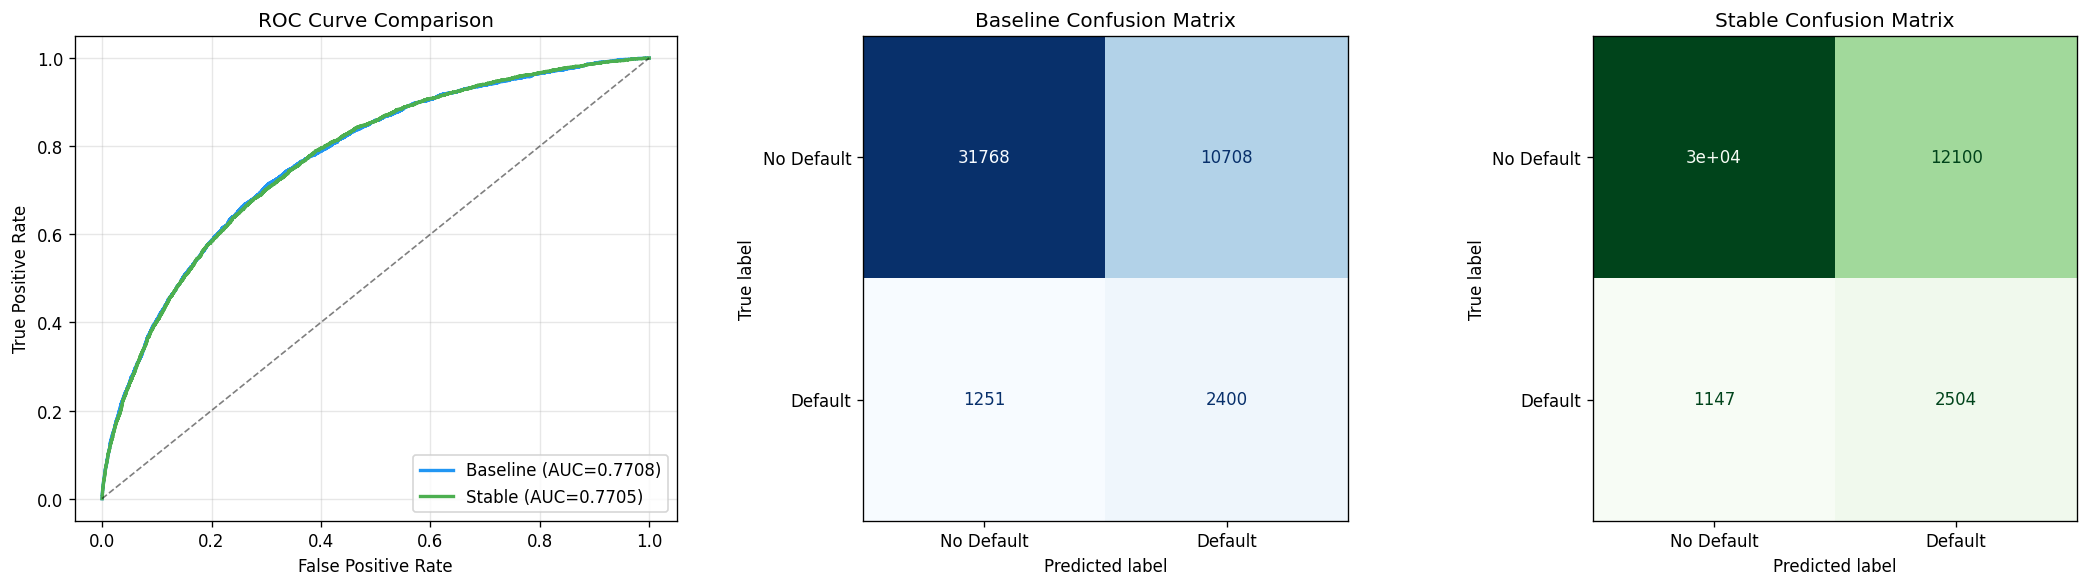

Saved: roc_and_confusion.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- ROC Curve ---
ax = axes[0]
for name, metrics, color in [("Baseline", baseline_metrics, "#2196F3"),
                               ("Stable", stable_metrics, "#4CAF50")]:
    fpr, tpr, _ = roc_curve(y_test, metrics["y_prob"])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={metrics['auc']:.4f})")
ax.plot([0,1], [0,1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# --- Confusion Matrices ---
for i, (name, metrics, cmap) in enumerate([
    ("Baseline", baseline_metrics, "Blues"),
    ("Stable", stable_metrics, "Greens")
]):
    ax = axes[i+1]
    ConfusionMatrixDisplay(metrics["cm"], display_labels=["No Default", "Default"]).plot(
        ax=ax, cmap=cmap, colorbar=False
    )
    ax.set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_and_confusion.png", bbox_inches="tight")
plt.show()
print("Saved: roc_and_confusion.png")

## 6. Feature Importance Comparison

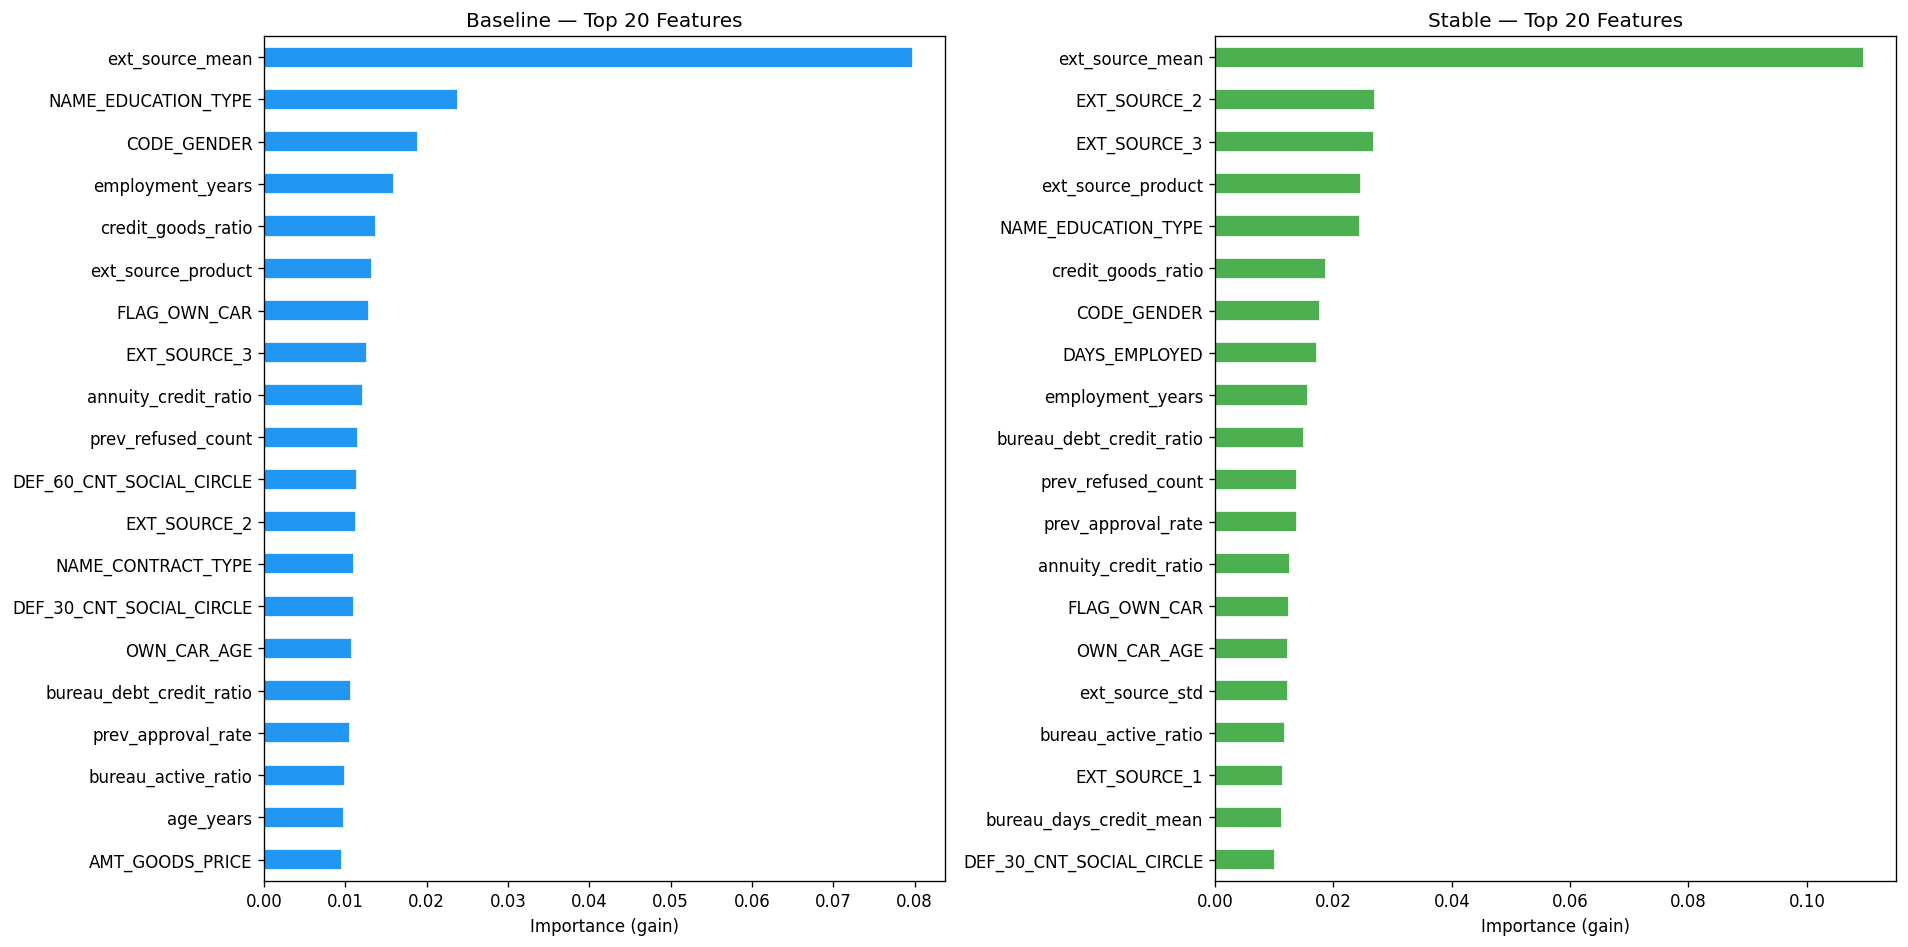

Saved: feature_importance.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, model, feat_cols, name, color in [
    (axes[0], baseline_model, feature_cols, "Baseline", "#2196F3"),
    (axes[1], stable_model, stable_features, "Stable", "#4CAF50"),
]:
    imp = pd.Series(model.feature_importances_, index=feat_cols).sort_values(ascending=True)
    top20 = imp.tail(20)
    top20.plot.barh(ax=ax, color=color, edgecolor="white")
    ax.set_title(f"{name} — Top 20 Features")
    ax.set_xlabel("Importance (gain)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance.png", bbox_inches="tight")
plt.show()
print("Saved: feature_importance.png")

## 7. Temporal Stability Evaluation

The test set is already sorted by `SK_ID_CURR` (time proxy). We split it into sequential folds and compute Gini per fold to measure **how the model degrades over time**.

**Gini Stability Score** (Kaggle Home Credit 2024):

$$\text{stability} = \overline{\text{Gini}} + 88 \cdot \min(0, \text{slope}) - 0.5 \cdot \text{std}(\text{residuals})$$

A stable model has: **high mean Gini, near-zero slope, low residual std**.

In [16]:
def gini_stability_score(gini_values):
    """Gini stability score from Kaggle Home Credit 2024 competition."""
    n = len(gini_values)
    if n < 2:
        return gini_values[0] if n == 1 else 0.0
    x = np.arange(n)
    coeffs = np.polyfit(x, gini_values, 1)
    slope = coeffs[0]
    predicted = np.polyval(coeffs, x)
    residuals = gini_values - predicted
    return float(np.mean(gini_values) + 88.0 * min(0, slope) - 0.5 * np.std(residuals))


def temporal_eval(model, X, y, feat_cols, n_folds=8):
    """Split test set into sequential folds (already sorted by SK_ID_CURR), compute Gini per fold."""
    fold_size = len(X) // n_folds
    gini_values = []
    for i in range(n_folds):
        start = i * fold_size
        end = start + fold_size if i < n_folds - 1 else len(X)
        X_fold = X[feat_cols].iloc[start:end]
        y_fold = y.iloc[start:end]
        if y_fold.nunique() < 2:
            continue
        auc = roc_auc_score(y_fold, model.predict_proba(X_fold)[:, 1])
        gini_values.append(2 * auc - 1)
    return np.array(gini_values)


N_FOLDS = 8
# Test set is already sorted by SK_ID_CURR — sequential folds = real time periods
baseline_gini = temporal_eval(baseline_model, X_test, y_test, feature_cols, N_FOLDS)
stable_gini = temporal_eval(stable_model, X_test, y_test, stable_features, N_FOLDS)

baseline_stab = gini_stability_score(baseline_gini)
stable_stab = gini_stability_score(stable_gini)

print(f"{'Fold':<8} {'SK_ID range':<25} {'Baseline Gini':>15} {'Stable Gini':>15}")
print("-" * 65)
fold_size = len(X_test) // N_FOLDS
for i in range(len(baseline_gini)):
    start = i * fold_size
    end = start + fold_size if i < N_FOLDS - 1 else len(X_test)
    id_min = X_test['SK_ID_CURR'].iloc[start]
    id_max = X_test['SK_ID_CURR'].iloc[min(end-1, len(X_test)-1)]
    print(f"Fold {i+1:<3} [{id_min:>6} - {id_max:>6}]       {baseline_gini[i]:>15.4f} {stable_gini[i]:>15.4f}")
print("-" * 65)
print(f"{'Mean':<34} {baseline_gini.mean():>15.4f} {stable_gini.mean():>15.4f}")
print(f"{'Std':<34} {baseline_gini.std():>15.4f} {stable_gini.std():>15.4f}")

b_slope = np.polyfit(np.arange(len(baseline_gini)), baseline_gini, 1)[0]
s_slope = np.polyfit(np.arange(len(stable_gini)), stable_gini, 1)[0]
print(f"{'Slope':<34} {b_slope:>15.6f} {s_slope:>15.6f}")
print(f"{'Stability Score':<34} {baseline_stab:>15.4f} {stable_stab:>15.4f}")

Fold     SK_ID range                 Baseline Gini     Stable Gini
-----------------------------------------------------------------
Fold 1   [402541 - 409520]                0.5136          0.5157
Fold 2   [409521 - 416381]                0.5666          0.5692
Fold 3   [416382 - 422858]                0.5544          0.5527
Fold 4   [422859 - 429413]                0.5208          0.5264
Fold 5   [429416 - 436209]                0.5439          0.5437
Fold 6   [436211 - 442911]                0.5394          0.5335
Fold 7   [442912 - 449570]                0.5589          0.5532
Fold 8   [449571 - 456255]                0.5352          0.5326
-----------------------------------------------------------------
Mean                                        0.5416          0.5409
Std                                         0.0172          0.0161
Slope                                     0.001084       -0.000030
Stability Score                             0.5331          0.5302


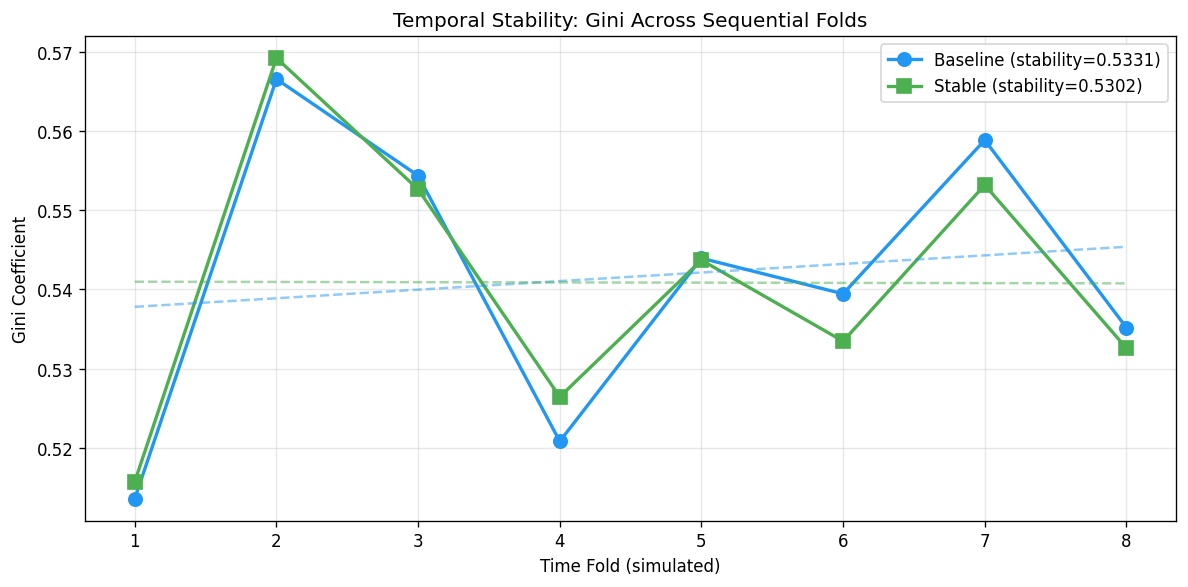

Saved: gini_stability.png


In [17]:
# --- Gini across folds visualization ---
fig, ax = plt.subplots(figsize=(10, 5))

folds = np.arange(1, N_FOLDS + 1)
ax.plot(folds, baseline_gini, "o-", color="#2196F3", lw=2, ms=8, label=f"Baseline (stability={baseline_stab:.4f})")
ax.plot(folds, stable_gini, "s-", color="#4CAF50", lw=2, ms=8, label=f"Stable (stability={stable_stab:.4f})")

# Trend lines
b_poly = np.polyfit(folds, baseline_gini, 1)
s_poly = np.polyfit(folds, stable_gini, 1)
ax.plot(folds, np.polyval(b_poly, folds), "--", color="#2196F3", alpha=0.5)
ax.plot(folds, np.polyval(s_poly, folds), "--", color="#4CAF50", alpha=0.5)

ax.set_xlabel("Time Fold (simulated)")
ax.set_ylabel("Gini Coefficient")
ax.set_title("Temporal Stability: Gini Across Sequential Folds")
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gini_stability.png", bbox_inches="tight")
plt.show()
print("Saved: gini_stability.png")

## 8. Cross-Validation Stability

5-fold Stratified CV to measure how consistent each model's AUC is across different data splits.

In [18]:
X_cv = pd.concat([X_train, X_val])
y_cv = pd.concat([y_train, y_val])

baseline_params = dict(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, eval_metric="auc", early_stopping_rounds=50,
)
stable_params = dict(
    n_estimators=500, max_depth=4, learning_rate=0.03,
    subsample=0.7, colsample_bytree=0.6, min_child_weight=20,
    reg_alpha=0.1, reg_lambda=2.0, gamma=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42, eval_metric="auc", early_stopping_rounds=50,
)

def run_cv(X, y, feat_cols, params, name, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs = []
    for fold, (tr_idx, vl_idx) in enumerate(skf.split(X[feat_cols], y), 1):
        m = xgb.XGBClassifier(**params, verbosity=0)
        m.fit(X[feat_cols].iloc[tr_idx], y.iloc[tr_idx],
              eval_set=[(X[feat_cols].iloc[vl_idx], y.iloc[vl_idx])], verbose=False)
        auc = roc_auc_score(y.iloc[vl_idx], m.predict_proba(X[feat_cols].iloc[vl_idx])[:, 1])
        aucs.append(auc)
        print(f"  {name} Fold {fold}: AUC = {auc:.4f}")
    aucs = np.array(aucs)
    print(f"  {name} Mean: {aucs.mean():.4f} +/- {aucs.std():.4f}  Range: {aucs.max()-aucs.min():.4f}")
    return aucs

print("Baseline CV:")
baseline_cv = run_cv(X_cv, y_cv, feature_cols, baseline_params, "Baseline")
print("\nStable CV:")
stable_cv = run_cv(X_cv, y_cv, stable_features, stable_params, "Stable")

Baseline CV:
  Baseline Fold 1: AUC = 0.7707
  Baseline Fold 2: AUC = 0.7641
  Baseline Fold 3: AUC = 0.7724
  Baseline Fold 4: AUC = 0.7669
  Baseline Fold 5: AUC = 0.7724
  Baseline Mean: 0.7693 +/- 0.0033  Range: 0.0083

Stable CV:
  Stable Fold 1: AUC = 0.7707
  Stable Fold 2: AUC = 0.7641
  Stable Fold 3: AUC = 0.7725
  Stable Fold 4: AUC = 0.7667
  Stable Fold 5: AUC = 0.7717
  Stable Mean: 0.7691 +/- 0.0032  Range: 0.0083


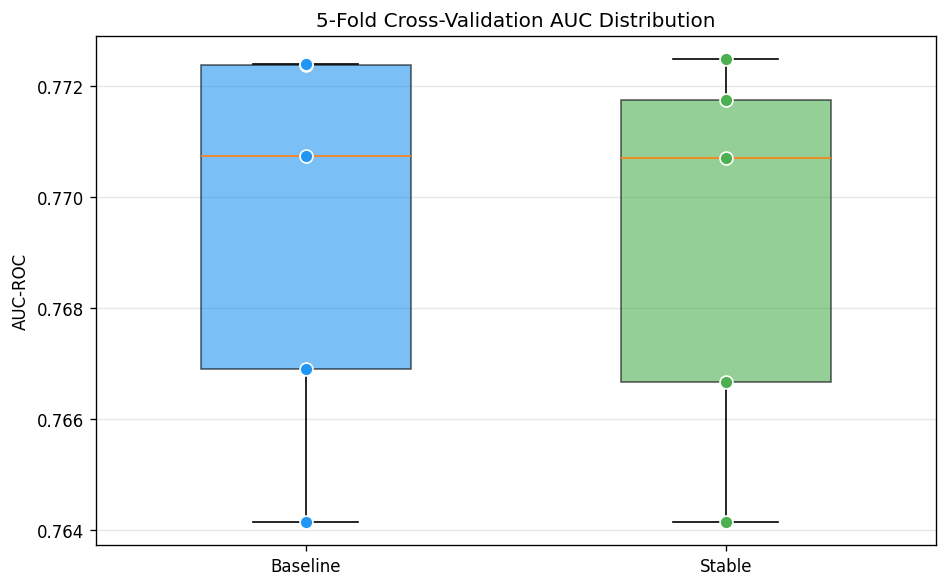

Saved: cv_auc_boxplot.png


In [19]:
# --- CV AUC box plot ---
fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.boxplot(
    [baseline_cv, stable_cv],
    labels=["Baseline", "Stable"],
    patch_artist=True,
    widths=0.5,
)
colors = ["#2196F3", "#4CAF50"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Overlay individual points
for i, (cv, color) in enumerate(zip([baseline_cv, stable_cv], colors)):
    ax.scatter([i+1]*len(cv), cv, color=color, s=60, zorder=5, edgecolors="white")

ax.set_ylabel("AUC-ROC")
ax.set_title("5-Fold Cross-Validation AUC Distribution")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cv_auc_boxplot.png", bbox_inches="tight")
plt.show()
print("Saved: cv_auc_boxplot.png")

## 9. Head-to-Head Comparison

In [20]:
rows = [
    ("AUC-ROC",                    baseline_metrics["auc"],  stable_metrics["auc"],  "higher"),
    ("Gini",                       baseline_metrics["gini"], stable_metrics["gini"], "higher"),
    ("Precision",                  baseline_metrics["precision"], stable_metrics["precision"], "higher"),
    ("Recall",                     baseline_metrics["recall"],    stable_metrics["recall"],    "higher"),
    ("F1-Score",                   baseline_metrics["f1"],        stable_metrics["f1"],        "higher"),
    ("CV AUC Mean",                baseline_cv.mean(),     stable_cv.mean(),     "higher"),
    ("CV AUC Std (lower=better)",  baseline_cv.std(),      stable_cv.std(),      "lower"),
    ("CV AUC Range (lower=better)",baseline_cv.max()-baseline_cv.min(), stable_cv.max()-stable_cv.min(), "lower"),
    ("Gini Stability Score",       baseline_stab,          stable_stab,          "higher"),
    ("Gini Std (lower=better)",    baseline_gini.std(),    stable_gini.std(),    "lower"),
    ("Num Features",               len(feature_cols),      len(stable_features), "lower"),
]

comp_df = pd.DataFrame(rows, columns=["Metric", "Baseline", "Stable", "Direction"])
comp_df["Winner"] = comp_df.apply(
    lambda r: "Baseline" if (r["Baseline"] > r["Stable"]) == (r["Direction"] == "higher")
              else "Stable" if (r["Stable"] > r["Baseline"]) == (r["Direction"] == "higher")
              else "Tie",
    axis=1
)

# Format numbers
for col in ["Baseline", "Stable"]:
    comp_df[col] = comp_df.apply(
        lambda r: f"{int(r[col])}" if r["Metric"] == "Num Features" else f"{r[col]:.4f}",
        axis=1
    )
comp_df = comp_df.drop("Direction", axis=1)
comp_df.style.apply(
    lambda row: ["" if row["Winner"] != "Baseline" else "font-weight:bold; color:#2196F3",
                 "" if row["Winner"] != "Baseline" else "font-weight:bold; color:#2196F3",
                 "" if row["Winner"] != "Stable" else "font-weight:bold; color:#4CAF50",
                 ""], axis=1, subset=["Baseline", "Stable", "Winner", "Metric"]
)

,Metric,Baseline,Stable,Winner
0,AUC-ROC,0.7708,0.7705,Baseline
1,Gini,0.5416,0.5411,Baseline
2,Precision,0.1831,0.1715,Baseline
3,Recall,0.6574,0.6858,Stable
4,F1-Score,0.2864,0.2743,Baseline
5,CV AUC Mean,0.7693,0.7691,Baseline
6,CV AUC Std (lower=better),0.0033,0.0032,Stable
7,CV AUC Range (lower=better),0.0083,0.0083,Baseline
8,Gini Stability Score,0.5331,0.5302,Baseline
9,Gini Std (lower=better),0.0172,0.0161,Stable


## 10. Save Models & Artifacts

In [21]:
# --- Save baseline model ---
baseline_dir = OUTPUT_DIR / "baseline"
baseline_dir.mkdir(parents=True, exist_ok=True)

with open(baseline_dir / "xgboost_model.pkl", "wb") as f:
    pickle.dump(baseline_model, f)
with open(baseline_dir / "feature_names.pkl", "wb") as f:
    pickle.dump(feature_cols, f)
with open(baseline_dir / "label_encoders.pkl", "wb") as f:
    pickle.dump(le_dict, f)
with open(baseline_dir / "metrics.pkl", "wb") as f:
    pickle.dump({
        "auc": baseline_metrics["auc"], "gini": baseline_metrics["gini"],
        "stability_score": baseline_stab,
        "cv_auc_mean": float(baseline_cv.mean()), "cv_auc_std": float(baseline_cv.std()),
    }, f)

print(f"Baseline model saved to: {baseline_dir.resolve()}")

# --- Save stable model ---
stable_dir = OUTPUT_DIR / "stable"
stable_dir.mkdir(parents=True, exist_ok=True)

with open(stable_dir / "xgboost_model.pkl", "wb") as f:
    pickle.dump(stable_model, f)
with open(stable_dir / "feature_names.pkl", "wb") as f:
    pickle.dump(stable_features, f)
with open(stable_dir / "label_encoders.pkl", "wb") as f:
    pickle.dump(le_dict, f)
with open(stable_dir / "dropped_features.pkl", "wb") as f:
    pickle.dump([f for f in feature_cols if f not in stable_features], f)
with open(stable_dir / "metrics.pkl", "wb") as f:
    pickle.dump({
        "auc": stable_metrics["auc"], "gini": stable_metrics["gini"],
        "stability_score": stable_stab,
        "cv_auc_mean": float(stable_cv.mean()), "cv_auc_std": float(stable_cv.std()),
    }, f)

print(f"Stable model saved to:   {stable_dir.resolve()}")

# --- Save test data for SHAP / fairness later ---
X_test[feature_cols].to_parquet(OUTPUT_DIR / "X_test.parquet")
y_test.to_frame().to_parquet(OUTPUT_DIR / "y_test.parquet")
X_train[feature_cols].to_parquet(OUTPUT_DIR / "X_train.parquet")

print(f"\nTest/train data saved for SHAP & fairness evaluation")
print("Done!")

Baseline model saved to: C:\Users\ngocanh\Downloads\Swin Hackathon\models\baseline
Stable model saved to:   C:\Users\ngocanh\Downloads\Swin Hackathon\models\stable

Test/train data saved for SHAP & fairness evaluation
Done!


## 11. DiCE Counterfactual Explanations

**"What's the smallest change that would flip the decision?"**

DiCE generates diverse counterfactual examples — alternative versions of a denied applicant's profile that would result in approval. This gives loan officers **actionable guidance** instead of just a rejection.

We use the **stable model** since it's the production model.

In [22]:
import dice_ml

# --- Build DiCE data object from training data ---
# DiCE requires NO missing values, so drop rows with NaN
train_dice = X_train[stable_features].copy()
train_dice["TARGET"] = y_train.values
train_dice = train_dice.dropna()

print(f"Training rows for DiCE: {len(train_dice):,} (dropped {len(X_train) - len(train_dice):,} rows with NaN)")

# IMPORTANT: Our categorical features are already label-encoded to integers.
# DiCE must treat them as continuous, otherwise it generates string values
# that XGBoost can't handle (KeyError: 'object').
# All features are numeric after encoding → all continuous for DiCE.
continuous_features = stable_features  # all features are numeric
categorical_features = []  # none — already label-encoded

print(f"All {len(continuous_features)} features treated as continuous (categoricals already label-encoded)")

# DiCE data object
dice_data = dice_ml.Data(
    dataframe=train_dice,
    continuous_features=continuous_features,
    outcome_name="TARGET",
)

# DiCE model object — wrap our trained stable XGBoost
dice_model = dice_ml.Model(
    model=stable_model,
    backend="sklearn",
    model_type="classifier",
)

# DiCE explainer — genetic method for proximity-optimized, diverse counterfactuals
dice_exp = dice_ml.Dice(dice_data, dice_model, method="genetic")

print("DiCE explainer ready (method=genetic).")

Training rows for DiCE: 6,906 (dropped 208,351 rows with NaN)
All 128 features treated as continuous (categoricals already label-encoded)
DiCE explainer ready (method=genetic).


In [23]:
# --- Find a denied applicant from the test set ---
# Predicted as default (class 1) by the stable model
test_preds = stable_model.predict(X_test[stable_features])
denied_mask = test_preds == 1
denied_df = X_test[stable_features][denied_mask]

print(f"Total denied applicants in test set: {len(denied_df):,}")

# Pick a denied applicant that has NO missing values (DiCE requirement)
denied_no_na = denied_df.dropna()
print(f"Denied applicants with no missing values: {len(denied_no_na):,}")

sample = denied_no_na.iloc[[0]]
sample_prob = stable_model.predict_proba(sample)[:, 1][0]

print(f"\nSelected applicant (index {sample.index[0]}):")
print(f"  Default probability: {sample_prob:.4f}")
print(f"  Prediction: DEFAULT (denied)")
print(f"  Missing values: {sample.isna().sum().sum()}")

# Show key features of this applicant
key_feats = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "DAYS_BIRTH",
             "DAYS_EMPLOYED", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
             "credit_income_ratio", "annuity_income_ratio"]
key_feats = [f for f in key_feats if f in stable_features]
print(f"\nKey features:")
for f in key_feats:
    print(f"  {f}: {sample[f].values[0]:.4f}")

Total denied applicants in test set: 14,604
Denied applicants with no missing values: 296

Selected applicant (index 261479):
  Default probability: 0.5236
  Prediction: DEFAULT (denied)
  Missing values: 0

Key features:
  AMT_INCOME_TOTAL: 135000.0000
  AMT_CREDIT: 360000.0000
  AMT_ANNUITY: 24354.0000
  DAYS_BIRTH: -14007.0000
  DAYS_EMPLOYED: -464.0000
  EXT_SOURCE_1: 0.5583
  EXT_SOURCE_2: 0.6427
  EXT_SOURCE_3: 0.2808
  credit_income_ratio: 2.6666
  annuity_income_ratio: 0.1804


In [24]:
# --- Generate counterfactual explanations ---
# Only vary features the applicant can REALISTICALLY change

print("Generating 4 diverse counterfactuals (genetic method)...")
print("(This may take 30-60 seconds)\n")

t0 = time.time()

# Actionable features only — things a loan officer can advise
ACTIONABLE_FEATURES = [
    "AMT_CREDIT",              # request smaller loan
    "AMT_ANNUITY",             # longer repayment term
    "AMT_GOODS_PRICE",         # cheaper purchase
    "AMT_INCOME_TOTAL",        # increase income
    "DAYS_EMPLOYED",           # longer employment (wait and reapply)
    "bureau_debt_sum",         # pay down existing debt
    "bureau_active_count",     # close unused credit lines
    "credit_income_ratio",     # derived: improves with income↑ or credit↓
    "annuity_income_ratio",    # derived: improves with income↑ or annuity↓
    "bureau_debt_credit_ratio",# derived: improves when debt is paid down
]

# Only include features that exist in stable_features
actionable = [f for f in ACTIONABLE_FEATURES if f in stable_features]
print(f"Actionable features: {len(actionable)}")
for f in actionable:
    print(f"  {f}: {sample[f].values[0]:.2f}")

# Ensure query instance matches DiCE data columns exactly
query = sample[stable_features].copy().reset_index(drop=True)

cf = dice_exp.generate_counterfactuals(
    query_instances=query,
    total_CFs=4,
    desired_class="opposite",
    features_to_vary=actionable,
    permitted_range={
        "AMT_INCOME_TOTAL": [50000, 1000000],
        "AMT_CREDIT": [45000, 2000000],
        "AMT_ANNUITY": [5000, 80000],
        "AMT_GOODS_PRICE": [40000, 2000000],
        "DAYS_EMPLOYED": [-7300, -30],        # 1 month to 20 years
        "bureau_debt_sum": [0, 5000000],
        "bureau_active_count": [0, 10],
        "credit_income_ratio": [0.1, 10],
        "annuity_income_ratio": [0.01, 0.5],
        "bureau_debt_credit_ratio": [0, 1],
    },
)

print(f"\nGenerated in {time.time()-t0:.1f}s\n")
cf.visualize_as_dataframe(show_only_changes=True)

Generating 4 diverse counterfactuals (genetic method)...
(This may take 30-60 seconds)

Actionable features: 10
  AMT_CREDIT: 360000.00
  AMT_ANNUITY: 24354.00
  AMT_GOODS_PRICE: 360000.00
  AMT_INCOME_TOTAL: 135000.00
  DAYS_EMPLOYED: -464.00
  bureau_debt_sum: 80735.18
  bureau_active_count: 2.00
  credit_income_ratio: 2.67
  annuity_income_ratio: 0.18
  bureau_debt_credit_ratio: 0.17


100%|██████████| 1/1 [00:00<00:00,  1.94it/s]


Generated in 0.5s

Query instance (original outcome : 1)


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,annuity_credit_ratio,age_years,employment_years,bureau_active_ratio,bureau_debt_credit_ratio,prev_approval_rate,ext_source_product,ext_source_mean,ext_source_std,TARGET
0,0,1,1,0,0,135000.0,360000.0,24354.0,360000.0,6,...,0.06765,38.349075,1.270363,0.2,0.173833,0.142857,0.100756,0.493935,0.189346,1



Diverse Counterfactual set (new outcome: 0)


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,annuity_credit_ratio,age_years,employment_years,bureau_active_ratio,bureau_debt_credit_ratio,prev_approval_rate,ext_source_product,ext_source_mean,ext_source_std,TARGET
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,0.0,0.1,-,-,-,0.0
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,0.0,0.1,-,-,-,0.0
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,0.0,0.1,-,-,-,0.0
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,0.0,0.1,-,-,-,0.0


In [25]:
# --- Summarize actionable changes for single sample ---
FEATURE_LABELS = {
    "AMT_CREDIT": "Loan amount",
    "AMT_ANNUITY": "Monthly payment",
    "AMT_GOODS_PRICE": "Purchase price",
    "AMT_INCOME_TOTAL": "Annual income",
    "DAYS_EMPLOYED": "Employment (days, negative=past)",
    "bureau_debt_sum": "Total outstanding debt",
    "bureau_active_count": "Active credit lines",
    "credit_income_ratio": "Loan-to-income ratio",
    "annuity_income_ratio": "Payment-to-income ratio",
    "bureau_debt_credit_ratio": "Debt-to-credit ratio",
}

def summarize_counterfactuals(cf_result, original_row, model, feat_cols, original_prob):
    """Print human-readable counterfactual summary."""
    cf_df = cf_result.cf_examples_list[0].final_cfs_df
    if cf_df is None or len(cf_df) == 0:
        print("  No valid counterfactuals found.")
        return

    for i, (_, row) in enumerate(cf_df.iterrows()):
        changes = []
        for col in actionable:
            orig_val = original_row[col]
            cf_val = row[col]
            if pd.notna(orig_val) and pd.notna(cf_val) and abs(orig_val - cf_val) > 1e-6:
                label = FEATURE_LABELS.get(col, col)
                if col == "DAYS_EMPLOYED":
                    orig_display = f"{abs(orig_val)/365.25:.1f} years"
                    cf_display = f"{abs(cf_val)/365.25:.1f} years"
                    changes.append((label, orig_display, cf_display))
                elif orig_val > 1000:
                    changes.append((label, f"${orig_val:,.0f}", f"${cf_val:,.0f}"))
                else:
                    changes.append((label, f"{orig_val:.3f}", f"{cf_val:.3f}"))

        new_prob = model.predict_proba(row[feat_cols].values.reshape(1, -1))[:, 1][0]

        if changes:
            print(f"\n  Path {i+1} (risk: {original_prob:.1%} → {new_prob:.1%}):")
            for label, orig, changed in changes:
                print(f"    • {label}: {orig} → {changed}")

# Run for single sample
print("=" * 70)
print(f"APPLICANT (index {sample.index[0]})")
print(f"Default risk: {sample_prob:.1%}")
print("=" * 70)
summarize_counterfactuals(cf, sample.iloc[0], stable_model, stable_features, sample_prob)

APPLICANT (index 261479)
Default risk: 52.4%

  Path 1 (risk: 52.4% → 46.5%):
    • Monthly payment: $24,354 → $20,794
    • Annual income: $135,000 → $180,000
    • Employment (days, negative=past): 1.3 years → 5.6 years
    • Total outstanding debt: $80,735 → $0
    • Loan-to-income ratio: 2.667 → 2.000
    • Payment-to-income ratio: 0.180 → 0.116
    • Debt-to-credit ratio: 0.174 → 0.000

  Path 2 (risk: 52.4% → 40.1%):
    • Loan amount: $360,000 → $45,000
    • Monthly payment: $24,354 → $5,000
    • Purchase price: $360,000 → $40,000
    • Employment (days, negative=past): 1.3 years → 0.6 years
    • Total outstanding debt: $80,735 → $12,807
    • Loan-to-income ratio: 2.667 → 2.240
    • Payment-to-income ratio: 0.180 → 0.171
    • Debt-to-credit ratio: 0.174 → 0.000

  Path 3 (risk: 52.4% → 39.6%):
    • Loan amount: $360,000 → $270,000
    • Monthly payment: $24,354 → $5,000
    • Purchase price: $360,000 → $315,000
    • Employment (days, negative=past): 1.3 years → 20.0 year

### 11b. Test with 10 Different Denied Applicants

Generate counterfactuals for 10 diverse denied applicants to verify the advice is consistently actionable.

In [26]:
# --- Test DiCE on 10 different denied applicants ---
# Pick 10 evenly spaced from the denied-no-NaN pool for diversity

n_scenarios = 10
step = max(1, len(denied_no_na) // n_scenarios)
test_indices = list(range(0, len(denied_no_na), step))[:n_scenarios]

print(f"Testing {len(test_indices)} denied applicants")
print(f"(from {len(denied_no_na)} denied applicants with no missing values)\n")

t0_all = time.time()

for scenario_num, idx in enumerate(test_indices, 1):
    test_sample = denied_no_na.iloc[[idx]]
    test_prob = stable_model.predict_proba(test_sample)[:, 1][0]
    test_query = test_sample[stable_features].copy().reset_index(drop=True)

    print(f"\n{'='*70}")
    print(f"SCENARIO {scenario_num}/10 — Applicant index {test_sample.index[0]}")
    print(f"Default risk: {test_prob:.1%}")
    print(f"  Income: ${test_sample['AMT_INCOME_TOTAL'].values[0]:,.0f}")
    print(f"  Loan: ${test_sample['AMT_CREDIT'].values[0]:,.0f}")
    print(f"  Monthly payment: ${test_sample['AMT_ANNUITY'].values[0]:,.0f}")
    print(f"  Employment: {abs(test_sample['DAYS_EMPLOYED'].values[0])/365.25:.1f} years")
    print(f"  Debt-to-credit: {test_sample['bureau_debt_credit_ratio'].values[0]:.3f}")
    print(f"{'='*70}")

    try:
        test_cf = dice_exp.generate_counterfactuals(
            query_instances=test_query,
            total_CFs=3,
            desired_class="opposite",
            features_to_vary=actionable,
            permitted_range={
                "AMT_INCOME_TOTAL": [50000, 1000000],
                "AMT_CREDIT": [45000, 2000000],
                "AMT_ANNUITY": [5000, 80000],
                "AMT_GOODS_PRICE": [40000, 2000000],
                "DAYS_EMPLOYED": [-7300, -30],
                "bureau_debt_sum": [0, 5000000],
                "bureau_active_count": [0, 10],
                "credit_income_ratio": [0.1, 10],
                "annuity_income_ratio": [0.01, 0.5],
                "bureau_debt_credit_ratio": [0, 1],
            },
        )
        summarize_counterfactuals(test_cf, test_sample.iloc[0], stable_model, stable_features, test_prob)
    except Exception as e:
        print(f"  Error: {e}")

print(f"\n\nTotal time for {n_scenarios} scenarios: {time.time()-t0_all:.1f}s")

Testing 10 denied applicants
(from 296 denied applicants with no missing values)


SCENARIO 1/10 — Applicant index 261479
Default risk: 52.4%
  Income: $135,000
  Loan: $360,000
  Monthly payment: $24,354
  Employment: 1.3 years
  Debt-to-credit: 0.174


100%|██████████| 1/1 [00:00<00:00,  2.93it/s]



  Path 1 (risk: 52.4% → 46.5%):
    • Monthly payment: $24,354 → $20,794
    • Annual income: $135,000 → $180,000
    • Employment (days, negative=past): 1.3 years → 5.6 years
    • Total outstanding debt: $80,735 → $0
    • Loan-to-income ratio: 2.667 → 2.000
    • Payment-to-income ratio: 0.180 → 0.116
    • Debt-to-credit ratio: 0.174 → 0.000

  Path 2 (risk: 52.4% → 47.1%):
    • Loan amount: $360,000 → $302,342
    • Monthly payment: $24,354 → $18,400
    • Purchase price: $360,000 → $261,000
    • Employment (days, negative=past): 1.3 years → 0.6 years
    • Total outstanding debt: $80,735 → $12,807
    • Loan-to-income ratio: 2.667 → 2.240
    • Payment-to-income ratio: 0.180 → 0.136
    • Debt-to-credit ratio: 0.174 → 0.000

  Path 3 (risk: 52.4% → 46.6%):
    • Loan amount: $360,000 → $337,500
    • Monthly payment: $24,354 → $16,875
    • Purchase price: $360,000 → $337,500
    • Employment (days, negative=past): 1.3 years → 3.5 years
    • Total outstanding debt: $80,735 → 

100%|██████████| 1/1 [00:00<00:00,  2.90it/s]



  Path 1 (risk: 56.6% → 48.4%):
    • Monthly payment: $21,906 → $19,476
    • Annual income: $157,500 → $144,000
    • Total outstanding debt: $1,326,966 → $1,273,910
    • Active credit lines: 6.000 → 2.000
    • Loan-to-income ratio: 4.286 → 4.687
    • Payment-to-income ratio: 0.139 → 0.135
    • Debt-to-credit ratio: 0.388 → 0.300

  Path 2 (risk: 56.6% → 41.9%):
    • Loan amount: $675,000 → $45,000
    • Monthly payment: $21,906 → $5,000
    • Annual income: $157,500 → $50,000
    • Employment (days, negative=past): 2.4 years → 20.0 years
    • Total outstanding debt: $1,326,966 → $944,897
    • Active credit lines: 6.000 → 5.000
    • Loan-to-income ratio: 4.286 → 3.832
    • Debt-to-credit ratio: 0.388 → 0.300

  Path 3 (risk: 56.6% → 37.9%):
    • Loan amount: $675,000 → $45,000
    • Monthly payment: $21,906 → $5,000
    • Annual income: $157,500 → $50,000
    • Employment (days, negative=past): 2.4 years → 20.0 years
    • Total outstanding debt: $1,326,966 → $944,897
    

...


  Path 1 (risk: 58.7% → 46.7%):
    • Loan amount: $426,645 → $337,500
    • Monthly payment: $21,915 → $5,000
    • Purchase price: $324,000 → $40,000
    • Annual income: $225,000 → $50,000
    • Employment (days, negative=past): 11.0 years → 20.0 years
    • Total outstanding debt: 760.500 → 0.000
    • Loan-to-income ratio: 1.896 → 0.100
    • Payment-to-income ratio: 0.097 → 0.120
    • Debt-to-credit ratio: 0.001 → 0.000

  Path 2 (risk: 58.7% → 47.6%):
    • Loan amount: $426,645 → $337,500
    • Monthly payment: $21,915 → $5,000
    • Purchase price: $324,000 → $40,000
    • Annual income: $225,000 → $50,000
    • Employment (days, negative=past): 11.0 years → 20.0 years
    • Total outstanding debt: 760.500 → 0.000
    • Loan-to-income ratio: 1.896 → 3.261
    • Payment-to-income ratio: 0.097 → 0.010
    • Debt-to-credit ratio: 0.001 → 0.000

  Path 3 (risk: 58.7% → 47.5%):
    • Loan amount: $426,645 → $337,500
    • Monthly payment: $21,915 → $5,000
    • Purchase price: $3

100%|██████████| 1/1 [00:08<00:00,  8.45s/it]


  Error: No counterfactuals found for any of the query points! Kindly check your configuration.

SCENARIO 10/10 — Applicant index 301950
Default risk: 62.9%
  Income: $450,000
  Loan: $521,280
  Monthly payment: $28,408
  Employment: 2.1 years
  Debt-to-credit: 0.163


100%|██████████| 1/1 [00:00<00:00,  3.10it/s]


  Path 1 (risk: 62.9% → 45.7%):
    • Loan amount: $521,280 → $45,000
    • Monthly payment: $28,408 → $5,000
    • Purchase price: $450,000 → $40,000
    • Annual income: $450,000 → $50,000
    • Total outstanding debt: $1,219,482 → $681,275
    • Active credit lines: 3.000 → 2.000
    • Loan-to-income ratio: 1.158 → 5.876
    • Payment-to-income ratio: 0.063 → 0.100
    • Debt-to-credit ratio: 0.163 → 0.000

  Path 2 (risk: 62.9% → 45.6%):
    • Loan amount: $521,280 → $45,000
    • Monthly payment: $28,408 → $5,000
    • Purchase price: $450,000 → $40,000
    • Annual income: $450,000 → $50,000
    • Total outstanding debt: $1,219,482 → $681,275
    • Active credit lines: 3.000 → 0.000
    • Loan-to-income ratio: 1.158 → 5.876
    • Payment-to-income ratio: 0.063 → 0.100
    • Debt-to-credit ratio: 0.163 → 0.000

  Path 3 (risk: 62.9% → 44.2%):
    • Loan amount: $521,280 → $45,000
    • Monthly payment: $28,408 → $5,000
    • Annual income: $450,000 → $225,000
    • Employment (da

In [ ]:
# --- Save DiCE explainer for backend use ---
dice_dir = OUTPUT_DIR / "stable"

with open(dice_dir / "dice_data.pkl", "wb") as f:
    pickle.dump(dice_data, f)
with open(dice_dir / "dice_explainer.pkl", "wb") as f:
    pickle.dump(dice_exp, f)
with open(dice_dir / "actionable_features.pkl", "wb") as f:
    pickle.dump(actionable, f)
with open(dice_dir / "feature_labels.pkl", "wb") as f:
    pickle.dump(FEATURE_LABELS, f)

print(f"DiCE artifacts saved to: {dice_dir.resolve()}")
print(f"  dice_data.pkl           — DiCE Data object (feature ranges & types)")
print(f"  dice_explainer.pkl      — DiCE explainer (ready to generate CFs)")
print(f"  actionable_features.pkl — {len(actionable)} features DiCE is allowed to vary")
print(f"  feature_labels.pkl      — human-readable labels for features")
print(f"\nDone!")